In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

known_wt = 'annotations/knownResults_wt.csv'
known_ko = 'annotations/knownResults_ko.csv'

In [ ]:
def compare_csv_files(file1, file2):
    """
    Compare WT and KO CSV files by matching 'Motif Name' and 'Consensus' columns.
    Returns rows with matching keys, labeled by source file.
    """
    df_wt = pd.read_csv(file1)
    df_ko = pd.read_csv(file2)

    df_wt.columns = ['motif_id', 'Consensus', 'pval_wt', 'logp_wt', 'qval_wt', 'n_wt', 'pct_wt', 'n_bg_wt', 'pct_bg_wt']
    df_ko.columns = ['motif_id', 'Consensus', 'pval_ko', 'logp_ko', 'qval_ko', 'n_ko', 'pct_ko', 'n_bg_ko', 'pct_bg_ko']
    
    # Create a composite key from Motif Name and Consensus columns
    for df in (df_wt, df_ko):
        df['key'] = df['motif_id'] + '|' + df['Consensus']
    
    # first merge: file1 vs file2
    merged = df_wt.merge(
        df_ko,
        on=['key', 'motif_id', 'Consensus'],
        how='inner',
        #suffixes=('_wt', '_ko')
    )
   
    merged.drop('key', axis=1, inplace=True)
    return merged

# Usage
result = compare_csv_files(known_wt, known_ko)
result.to_csv('matched_results.csv', index=False)
print(f"result shape: {result.shape}")
print(result.head())

# build a working "summary" dataframe for plotting
# filter to motifs where at least one group has p < 0.05
summary = result[
    (result['pval_wt'] < 0.05) |
    (result['pval_ko'] < 0.05) 
]
print(f"summary shape (after p<0.05 filter): {summary.shape}")
print(summary.head())
print(summary.columns.tolist())


result shape: (442, 16)
                                            motif_id             Consensus  \
0        EBF1(EBF)/Near-E2A-ChIP-Seq(GSE21512)/Homer          GTCCCCWGGGGA   
1  Oct2(POU,Homeobox)/Bcell-Oct2-ChIP-Seq(GSE2151...            ATATGCAAAT   
2  EBF2(EBF)/BrownAdipose-EBF2-ChIP-Seq(GSE97114)...       NABTCCCWDGGGAVH   
3                              GFY(?)/Promoter/Homer          ACTACAATTCCC   
4     Ronin(THAP)/ES-Thap11-ChIP-Seq(GSE51522)/Homer  RACTACAACTCCCAGVAKGC   

   pval_wt  logp_wt  qval_wt  n_wt  pct_wt  n_bg_wt pct_bg_wt  pval_ko  \
0    0.001    -9.06   0.0513   149  15.67%   2194.3    11.63%      1.0   
1    0.010    -6.76   0.2562    20   2.10%    181.2     0.96%      1.0   
2    0.010    -6.10   0.3293    98  10.30%   1452.7     7.70%      1.0   
3    0.010    -5.96   0.3293    46   4.84%    586.7     3.11%      0.1   
4    0.010    -5.83   0.3293    46   4.84%    590.7     3.13%      0.1   

   logp_ko  qval_ko  n_ko  pct_ko  n_bg_ko pct_bg_ko  
0  -0.0

C:\Users\Gabrielle\AppData\Local\Temp\ipykernel_24800\804764469.py:75: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


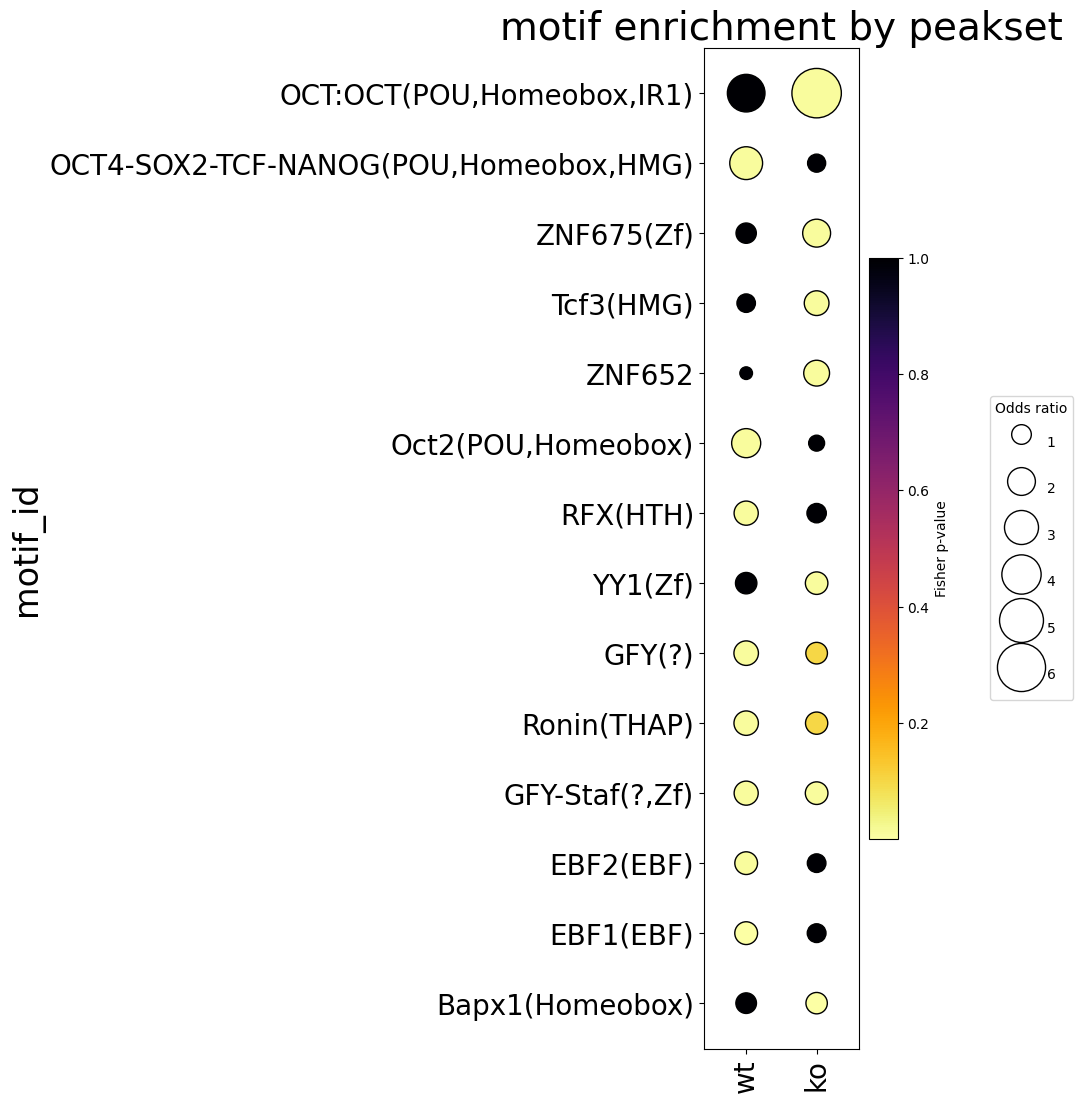

In [15]:
# --- make dot plot -----------------------------------------------------------
# reshape into long form for plotting
long = summary.melt(
    id_vars=['motif_id'],
    value_vars=['pct_wt','pct_ko'],
    var_name='pct_group', value_name='pct')
bg = summary.melt(
    id_vars=['motif_id'],
    value_vars=['pct_bg_wt','pct_bg_ko'],
    var_name='pct_bg_grp', value_name='pct_bg')
pvals = summary.melt(
    id_vars=['motif_id'],
    value_vars=['pval_wt','pval_ko'],
    var_name='group_p', value_name='pval')
long['pval'] = pvals['pval']
long['pct_bg'] = bg['pct_bg']
long['group'] = long['pct_group'].str.replace('pct_','')
group_order = ['wt','ko']
long['group_idx'] = long['group'].map({g:i for i,g in enumerate(group_order)})

# ensure pct column is numeric and drop any problematic rows
long['pct'] = long['pct'].str.replace('%','').astype(float)
long = long.dropna(subset=['pct','group_idx','motif_id'])
long['pct_bg'] = long['pct_bg'].str.replace('%','').astype(float)
long = long.dropna(subset=['pct_bg','group_idx','motif_id'])

#shorten motif_id
long['motif_id'] = long['motif_id'].str.split('/', n=1).str[0]
#long['motif_id'] = long['motif_id'].str.split('(', n=1).str[0]
long['or'] = long['pct'] / long['pct_bg']

# sanity check lengths for plotting
assert len(long['group_idx']) == len(long['motif_id']) == len(long['pct']), \
    "mismatch between x/y and size arrays"
long = long.sort_values(by='pct', ascending = False)

# plot using matplotlib
fig, ax = plt.subplots(figsize=(2.5, 13))
#sizes = (long['pct'].to_numpy() * 100 / long['pct_bg'].to_numpy())   # scale size as needed
sizes = long['or'] * 200
sc = ax.scatter(long['group_idx'],long['motif_id'],
                s=sizes,               # scale size as needed
                c=long['pval'], cmap='inferno_r', alpha=1, edgecolors='black')
ax.set_xticks(range(len(group_order)))
ax.set_xticklabels(group_order)
ax.set_ylabel('motif_id', fontsize = 24)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_title('motif enrichment by peakset', fontsize = 28)
plt.colorbar(sc, label='Fisher p-value')
#plt.legend(*sc.legend_elements("sizes", num=5), loc='best', bbox_to_anchor=(2, 0., 0.5, 0.5), 
 #          title="Size (units)")

handles, labels = sc.legend_elements(
    prop="sizes",
    num=5,
    func=lambda s: s/200
)

# make legend dots white with black outline
for h in handles:
    h.set_markerfacecolor('white')
    h.set_markeredgecolor('black')

ax.legend(
    handles,
    labels,
    title="Odds ratio",
    loc='center left',
    bbox_to_anchor=(1.8, 0.5),
    handleheight = 4
)
sc.set_clim(min(long['pval']), max(long['pval']))
plt.xticks(rotation=90)
plt.tight_layout()
plt.margins(0.6, 0.05) 
plt.savefig('known_motifs_odds_ratio_dotplot_subset.pdf')
plt.savefig('known_motifs_odds_ratio_dotplot_subset.png')
plt.show()